## **Simulate Helmholtz coils with Star n=5 shape in a single Axis**

Change root directory

In [1]:
import os
root_dir = os.path.dirname(os.path.abspath(''))
os.chdir(root_dir)
print(f"Directory changed to: {os.getcwd()}")

Directory changed to: /home/bespi123/git/helmholtzCoilsDesigner


Import Libraries

In [2]:
import time
import numpy as np
import pandas as pd
from src import helmCoils_simulator as sim
from src import plotMagneticField as hplot

Simulation Settings

In [3]:
# Initialize coil parameters
number_of_spires = 2
size_length =  1.15
distance_among_spires = 0.36
turns = 30
current = 1 
rotation_matrix = np.eye(3)
X_coil = sim.CoilParameters(number_of_spires, size_length, distance_among_spires, turns, current, rotation_matrix)

# Simulation settings
parallel_coils = 150
batch_Size = 120
grid_length_size = 0.01 #Space among evaluation points
num_seg = 100           #Numer of segments 

Set Spires geometry

In [4]:
##Spawn spires
spires_x_st = X_coil.star_spires(num_seg, star_points=5)

f0 = None
f0 = hplot.plot_spires(f0, spires_x_st, color='black', row=None, col=None)

# Plot the square spires
f0.show()

Set Simulation grid

In [5]:
# Generar grid
X, Y, Z = sim.generate_range([-0.8, 0.8],[-0.8, 0.8], [-0.8, 0.8], step_size_x = grid_length_size)

hplot.plot_grid(X, Y, Z, f0)

## Run Simulation ##

In [6]:
#Run simulations
start_time = time.time() #Count start time
x_coil_results_st = sim.coil_X_symmetric_simulation(X, Y, Z, X_coil, spires_x_st, batch_Size, enable_progress_bar=True)
end_time = time.time()   #Mark ending time

# Calcular la norma del campo magnético B = sqrt(Bx^2 + By^2 + Bz^2)
x_coil_results_st["B_norm"] = np.sqrt(x_coil_results_st["Bx"]**2 + x_coil_results_st["By"]**2 + x_coil_results_st["Bz"]**2)

#Calculate and show the simulation time
execution_time = end_time - start_time
print(f'Simulation finished in {execution_time/60} minutes...')

# Save results in a CSV file
output_file = 'data/x_coil_results_star.csv'
x_coil_results_st.to_csv(output_file, index=False)

Simulation Progress: 100%|██████████| 439/439 [02:57<00:00,  2.47it/s]


Simulation finished in 2.963944149017334 minutes...


## Plot result simulations

In [7]:
# Read data from previous simulations
x_coil_results_st = pd.read_csv('data/x_coil_results_star.csv')

reference_value:  7.218550289585856e-05


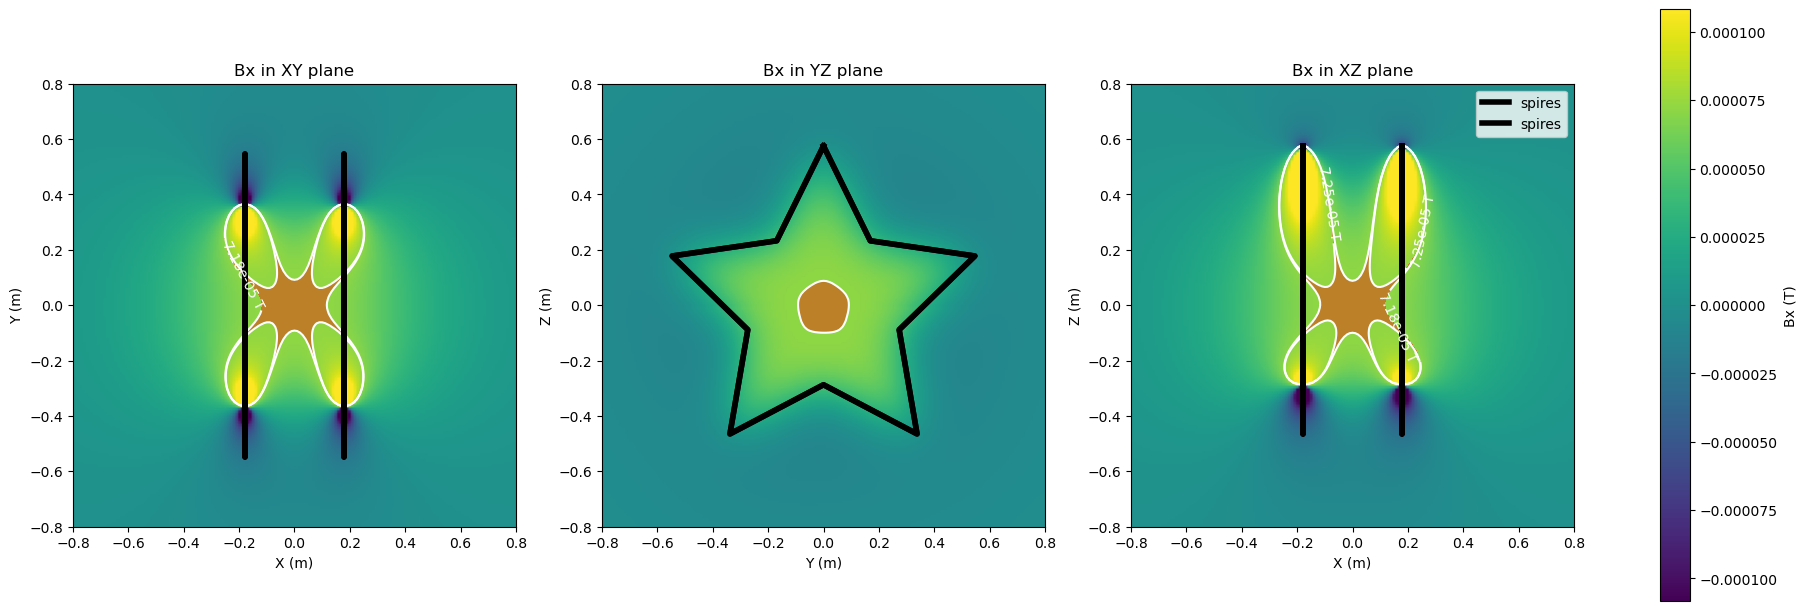

In [8]:
# Print the Bx component
hplot.plot_2d_magnetic_field(x_coil_results_st, spires_x_st, index='Bx', use_fixed_zaxis=True)

In [9]:
hplot.simple_3d_surface_plot(x_coil_results_st,spires_x_st,'Bx',True)

reference_value:  7.218550289585856e-05


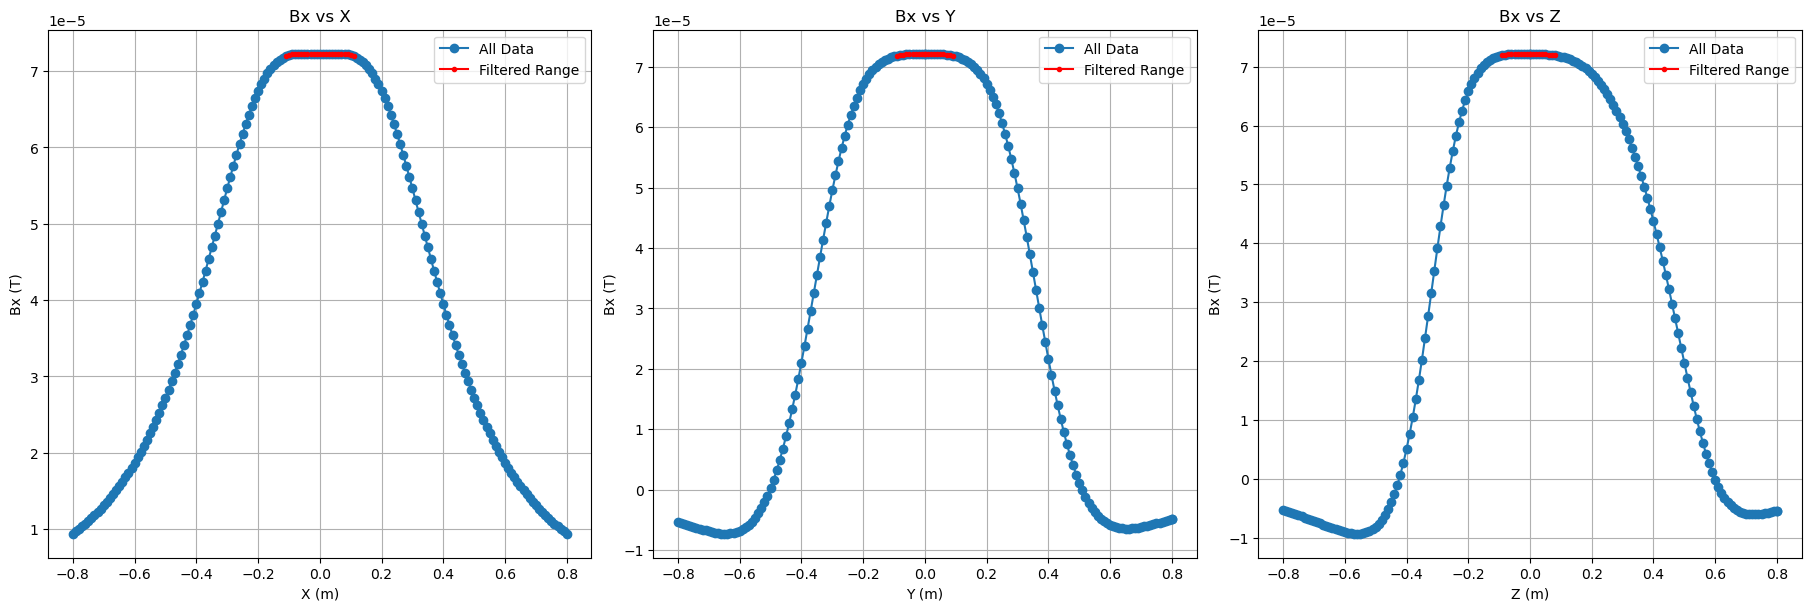

In [10]:
hplot.plot_mainAxis_field(x_coil_results_st, index='Bx')

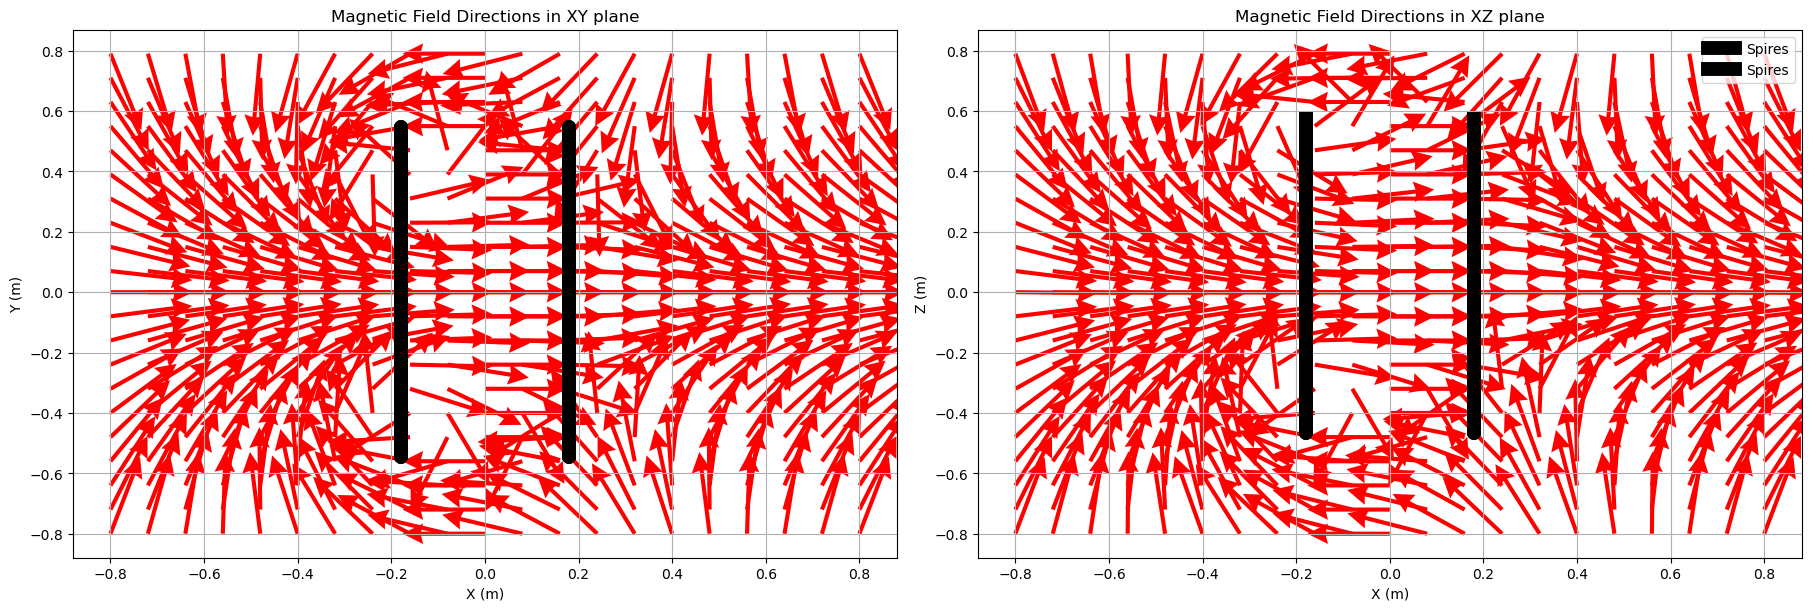

In [11]:
hplot.plot_magnetic_field_directions(x_coil_results_st, spires_x_st)